### Remap geothermal dataset (Davies, 2013) to tx2_0

In [1]:
%matplotlib inline

In [2]:
import xarray as xr
import xesmf, intake
import numpy as np
import datetime
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
today = datetime.date.today().strftime("%y%m%d")
print(today)

260527


In [4]:
fname = '../mesh/tx2_0v1_grid.nc'
ds_out = xr.open_dataset(fname).rename({'tlon': 'lon','tlat': 'lat', 'qlon': 'lon_b',
                                        'qlat': 'lat_b', 'nx' : 'xh', 'ny' : 'yh',
                                        'depth' : 'z_l'})
ds_out

<xarray.Dataset> Size: 4MB
Dimensions:  (yh: 128, xh: 180, nxp: 181, nyp: 129)
Dimensions without coordinates: yh, xh, nxp, nyp
Data variables: (12/20)
    lon      (yh, xh) float64 184kB ...
    lat      (yh, xh) float64 184kB ...
    ulon     (yh, nxp) float64 185kB ...
    ulat     (yh, nxp) float64 185kB ...
    vlon     (nyp, xh) float64 186kB ...
    vlat     (nyp, xh) float64 186kB ...
    ...       ...
    tarea    (yh, xh) float64 184kB ...
    tmask    (yh, xh) float64 184kB ...
    angle    (yh, xh) float64 184kB ...
    z_l      (yh, xh) float64 184kB ...
    ar       (yh, xh) float64 184kB ...
    egs      (yh, xh) float64 184kB ...
Attributes:
    Description:  CESM MOM6 2.0 degree grid
    Author:       Frank, Fred, Gustavo, William (chengz@ucar.edu)
    Created:      2026-05-27T13:37:18.621282
    type:         Glogal 2.0 degree grid file

In [5]:
infile = '/glade/campaign/cgd/oce/datasets/obs/geothermal/geothermal_davies2013_ncar.nc'
ds_in = xr.open_dataset(infile).rename({'tlon': 'lon','tlat': 'lat', 'qlon': 'lon_b',
                                        'qlat': 'lat_b'})
ds_in

<xarray.Dataset> Size: 56MB
Dimensions:        (yh: 1080, xh: 1440, yq: 1081, xq: 1441)
Coordinates:
  * yh             (yh) float32 4kB 0.5 1.5 2.5 ... 1.078e+03 1.078e+03 1.08e+03
  * xh             (xh) float32 6kB 0.5 1.5 2.5 ... 1.438e+03 1.438e+03 1.44e+03
Dimensions without coordinates: yq, xq
Data variables:
    geothermal_hf  (yh, xh) float32 6MB ...
    lat            (yh, xh) float64 12MB ...
    lon            (yh, xh) float64 12MB ...
    lat_b          (yq, xq) float64 12MB ...
    lon_b          (yq, xq) float64 12MB ...
Attributes:
    title:          Geothermal heat flow from Davies, 2013, re-gridded to OM4...
    reference:      Davies, J. Huw, 2013: Global map of solid Earth surface h...
    reference_url:  http://dx.doi.org/10.1002/ggge.20271

In [6]:
def regrid_tracer(fld, ds_in, ds_out, method='conservative'):

    regrid = xesmf.Regridder(
        ds_in,
        ds_out,
        method=method,
        periodic=True,
    )
    fld_out = regrid(ds_in[fld])
    return fld_out

#### Potential temperature

In [7]:
geothermal_hf = regrid_tracer('geothermal_hf', ds_in, ds_out)
geothermal_hf

<xarray.DataArray (yh: 128, xh: 180)> Size: 92kB
array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.00749222, 0.0074239 , 0.00740111, ..., 0.00796864, 0.00776485,
        0.00760594],
       ...,
       [0.05806259, 0.0580663 , 0.05667386, ..., 0.05631752, 0.05792148,
        0.05791016],
       [0.05802369, 0.05800075, 0.05659585, ..., 0.05637704, 0.05791089,
        0.057934  ],
       [0.05801988, 0.05795307, 0.05654731, ..., 0.05647039, 0.05791961,
        0.05794571]], shape=(128, 180), dtype=float32)
Dimensions without coordinates: yh, xh
Attributes:
    regrid_method:  conservative

In [8]:
geothermal_hf = geothermal_hf.rename('geothermal_hf')

##### Visual inspection
Make sure original and remapped plots look similar.

Text(0.5, 0.98, 'geothermal_hf')

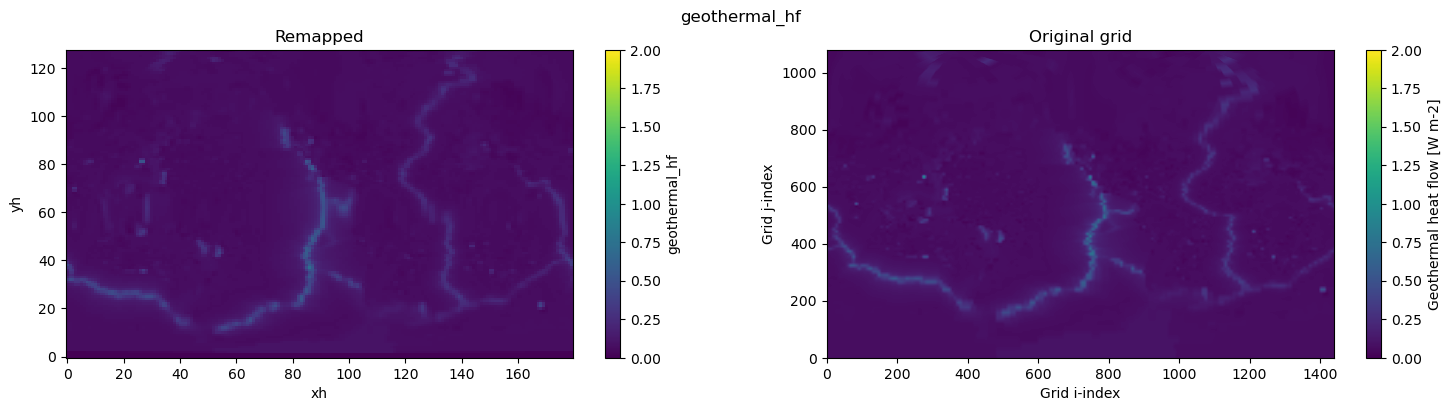

In [9]:
# visual inspection. Make sure original and remapped plots look similar
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18,4))
geothermal_hf.plot.pcolormesh(ax=axes[0], vmin=0,vmax=2)
ds_in['geothermal_hf'].plot.pcolormesh(ax=axes[1], vmin=0,vmax=2)
axes[0].set_title('Remapped')
axes[1].set_title('Original grid')
plt.suptitle('geothermal_hf')

In [10]:
data = xr.DataArray(geothermal_hf.data, dims=('yh', 'xh'), name='geothermal_hf')
data

<xarray.DataArray 'geothermal_hf' (yh: 128, xh: 180)> Size: 92kB
array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.00749222, 0.0074239 , 0.00740111, ..., 0.00796864, 0.00776485,
        0.00760594],
       ...,
       [0.05806259, 0.0580663 , 0.05667386, ..., 0.05631752, 0.05792148,
        0.05791016],
       [0.05802369, 0.05800075, 0.05659585, ..., 0.05637704, 0.05791089,
        0.057934  ],
       [0.05801988, 0.05795307, 0.05654731, ..., 0.05647039, 0.05791961,
        0.05794571]], shape=(128, 180), dtype=float32)
Dimensions without coordinates: yh, xh

In [11]:
data

<xarray.DataArray 'geothermal_hf' (yh: 128, xh: 180)> Size: 92kB
array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.00749222, 0.0074239 , 0.00740111, ..., 0.00796864, 0.00776485,
        0.00760594],
       ...,
       [0.05806259, 0.0580663 , 0.05667386, ..., 0.05631752, 0.05792148,
        0.05791016],
       [0.05802369, 0.05800075, 0.05659585, ..., 0.05637704, 0.05791089,
        0.057934  ],
       [0.05801988, 0.05795307, 0.05654731, ..., 0.05647039, 0.05791961,
        0.05794571]], shape=(128, 180), dtype=float32)
Dimensions without coordinates: yh, xh

In [12]:
data = xr.DataArray(geothermal_hf.data, dims=('yh', 'xh'), name='geothermal_hf')

# Global attrs
data.attrs['long_name'] = 'Geothermal heat flow'
data.attrs['standard_name'] = 'upward_geothermal_heat_flux_at_sea_floor'
data.attrs['units'] = 'W m-2'
data.attrs['cell_methods'] = 'area: mean'

# Create a dataset and add the DataArray to it
dataset = xr.Dataset({'geothermal_hf': data})

dataset.attrs['description'] = 'Geothermal heat flow from Davies, 2013, re-gridded to tx2_3'
dataset.attrs['author'] = 'Gustavo Marques (gmarques@ucar.edu)'
dataset.attrs['date'] = today
dataset.attrs['infile'] = infile
dataset.attrs['url'] = 'https://github.com/NCAR/tx2_0/geothermal'
# save
fname = 'geothermal_davies2013_tx2_0v1_{}.nc'.format(today)

dataset.to_netcdf(fname, 
                  engine="netcdf4",
                  format="NETCDF3_64BIT_DATA",
                  encoding={'geothermal_hf': {'_FillValue': None}})